In [1]:
from pathlib import Path
import polars as pl
import matplotlib.pyplot as plt
import mplhep as hep
plt.style.use(hep.style.ATLAS)

from utils import add_project_root_to_sys_path
add_project_root_to_sys_path()
from neuralnet.models.binary_classification import BinaryClassificationJob
from neuralnet.plotting import plot_metric_comparison

2026-05-29 23:39:20.262823: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-29 23:39:20.297095: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-29 23:39:20.987917: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-29 23:39:20.988227: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not 

In [2]:
jobs_dir = Path.home() / "data" / "neuralnet_jobs"
jobs = {
    'mlp':{
        "model_label": "MLP",
        "path": jobs_dir / 'mlp',
        "color": "C0",
        "marker": "o",
    },
    'basic_entangler': {
        "model_label": "Basic Entangler",
        "path": jobs_dir / 'basic_entangler',
        "color": "C1",
        "marker": "s",
    },
    'strongly_entangling': {
        "model_label": "Strongly Entangling",
        "path": jobs_dir / 'strongly_entangling',
        "color": "C2",
        "marker": "^",
    },
    'hardware_efficient': {
        "model_label": "Hardware Efficient",
        "path": jobs_dir / 'hardware_efficient',
        "color": "C3",
        "marker": "D",
    }
}

In [3]:
for job in jobs.values():
    print(f"Loading job: {job['model_label']}")
    job_instance = BinaryClassificationJob.load(job['path'])
    job['job'] = job_instance

/home/lucasbanunes/miniconda3/envs/neuralnet/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 10 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Loading job: MLP
Loading job: Basic Entangler
Loading job: Strongly Entangling
Loading job: Hardware Efficient


In [4]:
metric_prefixes = (
    'train', 'val', 'test'
)
continue_if_ends = (
    'loss',
    'auc'
)
for job in jobs.values():
    print(f"Processing job: {job['model_label']}")
    aggregation_expressions = list()
    df = job['job'].results.clone()
    df = df.with_columns(
        pl.col('val.sp_index').list.arg_max().alias('max_sp_idx')
    )
    max_sp_idx = pl.col('max_sp_idx')
    for col in df.columns:
        if not col.startswith(metric_prefixes) or col.endswith(continue_if_ends):
            continue
        alias = f'{col}_max_sp'
        max_sp_metric = pl.col(col).list.get(max_sp_idx).alias(alias)
        df = df.with_columns(max_sp_metric)
        aggregation_expressions.append(pl.col(alias).mean().alias(f'{alias}.mean'))
        aggregation_expressions.append(pl.col(alias).std().alias(f'{alias}.std'))
        aggregation_expressions.append(pl.col(alias).min().alias(f'{alias}.min'))
        aggregation_expressions.append(pl.col(alias).max().alias(f'{alias}.max'))
    
    job['results'] = df
    job['results_by_fold'] = df.group_by('fold').agg(*aggregation_expressions)

Processing job: MLP
Processing job: Basic Entangler
Processing job: Strongly Entangling
Processing job: Hardware Efficient


<>:22: SyntaxWarning: invalid escape sequence '\m'
<>:22: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_43911/31923680.py:22: SyntaxWarning: invalid escape sequence '\m'
  title=f'{metric_label} by Fold $\mu \pm 3 \sigma$'
/home/lucasbanunes/workspaces/neuralnet/neuralnet/plotting.py:83: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  ax.errorbar(
/home/lucasbanunes/workspaces/neuralnet/neuralnet/plotting.py:107: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  ref_ax.errorbar(
/tmp/ipykernel_43911/31923680.py:24: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


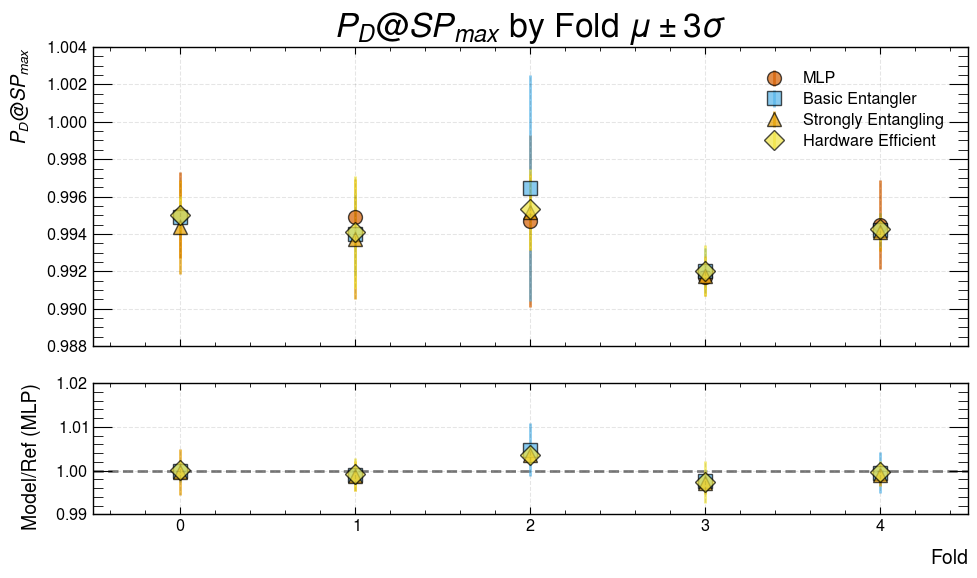

In [5]:
metric = 'train.tpr_max_sp'
metric_label=r'$P_D @ SP_{max}$'
fig, _, _ = plot_metric_comparison(
    metric_label=metric_label,
    ref_name='mlp',
    to_plot={
        job_name: {
            'label': job['model_label'],
            'x': job['results_by_fold']['fold'],
            'y': job['results_by_fold'][f'{metric}.mean'],
            'yerr': 3*job['results_by_fold'][f'{metric}.std'],
            'color': job['color'],
            'marker': job['marker']
        }
        for job_name, job in jobs.items()
    },
    fig_kwargs={
        'figsize': (10, 6)
    },
    xlim=(-0.5, 4.5),
    xticks=range(5),
    title=f'{metric_label} by Fold $\mu \pm 3 \sigma$'
)
fig.show()

<>:22: SyntaxWarning: invalid escape sequence '\m'
<>:22: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_43911/198638419.py:22: SyntaxWarning: invalid escape sequence '\m'
  title=f'{metric_label} by Fold $\mu \pm 3 \sigma$',
/tmp/ipykernel_43911/198638419.py:26: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


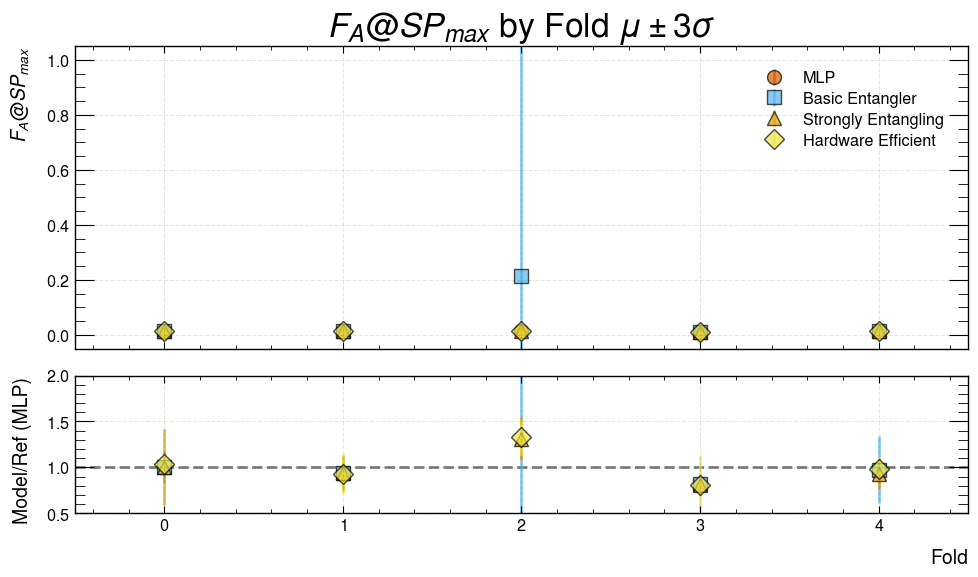

In [7]:
metric = 'train.fpr_max_sp'
metric_label=r'$F_A @ SP_{max}$'
fig, _, _ = plot_metric_comparison(
    metric_label=metric_label,
    ref_name='mlp',
    to_plot={
        job_name: {
            'label': job['model_label'],
            'x': job['results_by_fold']['fold'],
            'y': job['results_by_fold'][f'{metric}.mean'],
            'yerr': 3*job['results_by_fold'][f'{metric}.std'],
            'color': job['color'],
            'marker': job['marker']
        }
        for job_name, job in jobs.items()
    },
    fig_kwargs={
        'figsize': (10, 6)
    },
    xlim=(-0.5, 4.5),
    xticks=range(5),
    title=f'{metric_label} by Fold $\mu \pm 3 \sigma$',
    scatter_ylim=(-0.05, 1.05),
    ref_ratio_ylim=(0.5, 2)
)
fig.show()